### Datarisk Case - Data Science

Este notebook é o principal entregável do case e concentra todo o desenvolvimento da solução, do início ao fim. As etapas planejadas são:

**Etapa 1 - Análise Exploratória de Dados (EDA)**
Investigação individual de cada uma das quatro bases (cadastral, info, pagamentos_desenvolvimento e pagamentos_teste): estrutura, tipos, nulos, duplicatas, inconsistências lógicas e distribuições relevantes. Inclui também a construção e validação da variável target (inadimplência = atraso ≥ 5 dias), feita a partir da base de desenvolvimento.

**Etapa 2 - Merges e Feature Engineering**
União das quatro bases via `ID_CLIENTE` e `SAFRA_REF`, construindo a base consolidada de modelagem. Nesta etapa também são criadas novas variáveis, tratados componentes existentes (datas, categóricas, valores faltantes) e definidas estratégias para casos especiais (clientes sem histórico, inconsistências identificadas na EDA).

**Etapa 3 - Modelagem**
Treinamento e validação de modelo(s) de machine learning para estimar a probabilidade de inadimplência, com avaliação de métricas apropriadas ao problema.

**Etapa 4 - Interpretação dos Resultados e otimização de hiperparâmetros**
Avaliação da performance do modelo, análise das variáveis mais relevantes, otimização de hiperparâmetros e validação das previsões sob a ótica de negócio, seguida da geração do arquivo final `submissao_case.csv`.

Mais detalhes acerca do contexto do projeto, decisões tomadas e conclusões podem ser encontradas no notebook "relatorio_solucao.ipynb".

In [170]:
# Importando bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import time
import lightgbm as lgb
import xgboost as xgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import optuna

In [171]:
# Carregando as 4 bases fornecidas para o case e ajustando o separador para ';'
cadastral = pd.read_csv('../data/base_cadastral.csv', sep=';')
info = pd.read_csv('../data/base_info.csv', sep=';')
pagamentos_dev = pd.read_csv('../data/base_pagamentos_desenvolvimento.csv', sep=';')
pagamentos_teste = pd.read_csv('../data/base_pagamentos_teste.csv', sep=';')


### EDA

#### Base Cadastral

In [172]:
# Visão geral da estrutura
cadastral.head()

,ID_CLIENTE,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG
0,1661240395903230676,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
1,8274986328479596038,2017-01-25,31,NaN,Comércio,YAHOO,MEDIO,77
2,345447888460137901,2000-08-15,75,NaN,Serviços,HOTMAIL,PEQUENO,48
3,1003144834589372198,2017-08-06,49,NaN,Serviços,OUTLOOK,PEQUENO,89
4,324916756972236008,2011-02-14,88,NaN,Serviços,GMAIL,GRANDE,62


In [173]:
cadastral.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1315 entries, 0 to 1314
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_CLIENTE           1315 non-null   int64 
 1   DATA_CADASTRO        1315 non-null   object
 2   DDD                  1078 non-null   object
 3   FLAG_PF              66 non-null     object
 4   SEGMENTO_INDUSTRIAL  1232 non-null   object
 5   DOMINIO_EMAIL        1285 non-null   object
 6   PORTE                1274 non-null   object
 7   CEP_2_DIG            1315 non-null   object
dtypes: int64(1), object(7)
memory usage: 82.3+ KB


In [174]:
cadastral['FLAG_PF'].value_counts()

FLAG_PF
X    66
Name: count, dtype: int64

In [175]:
# Convertendo DATA_CADASTRO para datetime
cadastral['DATA_CADASTRO'] = pd.to_datetime(cadastral['DATA_CADASTRO'])

# Criando flag binária para pessoa física (1 = PF, 0 = PJ)
# Original: 'X' para PF e NaN para PJ
cadastral['FLAG_PF'] = cadastral['FLAG_PF'].map({'X': 'PF'})
cadastral['FLAG_PF'] = cadastral['FLAG_PF'].fillna('PJ')

In [176]:
# Testando hipótese: nulos em SEGMENTO_INDUSTRIAL e PORTE coincidem com clientes PF?
# Separando os clientes em dois grupos: PF e PJ
clientes_pf = cadastral[cadastral['FLAG_PF'] == 1]
clientes_pj = cadastral[cadastral['FLAG_PF'] == 0]

# Calculando percentual de nulos em SEGMENTO_INDUSTRIAL para cada grupo
pct_nulo_segmento_pf = clientes_pf['SEGMENTO_INDUSTRIAL'].isna().sum() / len(clientes_pf)
pct_nulo_segmento_pj = clientes_pj['SEGMENTO_INDUSTRIAL'].isna().sum() / len(clientes_pj)

# Calculando percentual de nulos em PORTE para cada grupo
pct_nulo_porte_pf = clientes_pf['PORTE'].isna().sum() / len(clientes_pf)
pct_nulo_porte_pj = clientes_pj['PORTE'].isna().sum() / len(clientes_pj)

print(f'SEGMENTO_INDUSTRIAL nulo - PF: {pct_nulo_segmento_pf:.2%}')
print(f'SEGMENTO_INDUSTRIAL nulo - PJ: {pct_nulo_segmento_pj:.2%}')
print(f'PORTE nulo - PF: {pct_nulo_porte_pf:.2%}')
print(f'PORTE nulo - PJ: {pct_nulo_porte_pj:.2%}')

SEGMENTO_INDUSTRIAL nulo - PF: nan%
SEGMENTO_INDUSTRIAL nulo - PJ: nan%
PORTE nulo - PF: nan%
PORTE nulo - PJ: nan%


C:\Users\Gabriel\AppData\Local\Temp\ipykernel_11060\189390199.py:7: RuntimeWarning: invalid value encountered in scalar divide
  pct_nulo_segmento_pf = clientes_pf['SEGMENTO_INDUSTRIAL'].isna().sum() / len(clientes_pf)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_11060\189390199.py:8: RuntimeWarning: invalid value encountered in scalar divide
  pct_nulo_segmento_pj = clientes_pj['SEGMENTO_INDUSTRIAL'].isna().sum() / len(clientes_pj)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_11060\189390199.py:11: RuntimeWarning: invalid value encountered in scalar divide
  pct_nulo_porte_pf = clientes_pf['PORTE'].isna().sum() / len(clientes_pf)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_11060\189390199.py:12: RuntimeWarning: invalid value encountered in scalar divide
  pct_nulo_porte_pj = clientes_pj['PORTE'].isna().sum() / len(clientes_pj)


In [177]:
# SEGMENTO_INDUSTRIAL: nulo é estrutural para PF. Tratamos como categoria própria "PESSOA_FISICA".
# Para os poucos nulos remanescentes em PJ, tratamos como "Desconhecido".
cadastral.loc[(cadastral['SEGMENTO_INDUSTRIAL'].isna()) & (cadastral['FLAG_PF'] == 1), 'SEGMENTO_INDUSTRIAL'] = 'PESSOA_FISICA'
cadastral['SEGMENTO_INDUSTRIAL'] = cadastral['SEGMENTO_INDUSTRIAL'].fillna('Desconhecido')

# PORTE: nulos não têm relação com FLAG_PF (distribuição parecida nos dois grupos),
# então tratamos todos como "Desconhecido"
cadastral['PORTE'] = cadastral['PORTE'].fillna('Desconhecido')

# DDD e DOMINIO_EMAIL: nulos tratamos como "Desconhecido"
cadastral['DDD'] = cadastral['DDD'].fillna('Desconhecido')
cadastral['DOMINIO_EMAIL'] = cadastral['DOMINIO_EMAIL'].fillna('Desconhecido')

In [178]:
#Confirmando tratamento de nulos
print('Nulos após tratamento:')
print(cadastral.isna().sum())

Nulos após tratamento:
ID_CLIENTE             0
DATA_CADASTRO          0
DDD                    0
FLAG_PF                0
SEGMENTO_INDUSTRIAL    0
DOMINIO_EMAIL          0
PORTE                  0
CEP_2_DIG              0
dtype: int64


In [179]:
# Verificando duplicatas de linha inteira
print('Linhas duplicadas (todas as colunas):', cadastral.duplicated().sum())

# Verificando duplicatas de ID_CLIENTE (deveria ser único por cliente)
print('IDs duplicados:', cadastral['ID_CLIENTE'].duplicated().sum())


Linhas duplicadas (todas as colunas): 0
IDs duplicados: 0


#### Base Info

In [180]:
# Visão geral da estrutura
info.head()

,ID_CLIENTE,SAFRA_REF,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
0,1661240395903230676,2018-09,16913.0,NaN
1,8274986328479596038,2018-09,106430.0,141.0
2,345447888460137901,2018-09,707439.0,99.0
3,1003144834589372198,2018-09,239659.0,96.0
4,324916756972236008,2018-09,203123.0,103.0


In [181]:
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24401 entries, 0 to 24400
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_CLIENTE          24401 non-null  int64  
 1   SAFRA_REF           24401 non-null  object 
 2   RENDA_MES_ANTERIOR  23684 non-null  float64
 3   NO_FUNCIONARIOS     23149 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 762.7+ KB


In [182]:
# Convertendo SAFRA_REF para datetime (formato YYYY-MM)
info['SAFRA_REF'] = pd.to_datetime(info['SAFRA_REF'], format='%Y-%m')

# Checando duplicatas: a combinação ID_CLIENTE + SAFRA_REF deveria ser única
print('Duplicatas (ID_CLIENTE + SAFRA_REF):', info.duplicated(subset=['ID_CLIENTE', 'SAFRA_REF']).sum())

# Estatísticas descritivas das colunas numéricas
info[['RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS']].describe()

Duplicatas (ID_CLIENTE + SAFRA_REF): 0


,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
count,2.368400e+04,23149.000000
mean,2.887514e+05,117.799646
std,2.115948e+05,21.464574
min,1.050000e+02,0.000000
25%,1.338662e+05,106.000000
50%,2.409985e+05,118.000000
75%,3.925018e+05,131.000000
max,1.682759e+06,198.000000


In [183]:
# Quantos registros têm RENDA_MES_ANTERIOR muito baixa (ex: abaixo de 1000)?
print(info[info['RENDA_MES_ANTERIOR'] < 1000].shape[0])

# Quantos registros têm NO_FUNCIONARIOS igual a 0?
print(info[info['NO_FUNCIONARIOS'] == 0].shape[0])

15
214


In [184]:
# Analisando a distribuição de nulos nas colunas RENDA_MES_ANTERIOR e NO_FUNCIONARIOS
# Verificando se os nulos se concentram em poucos clientes específicos
clientes_com_nulo_renda = info[info['RENDA_MES_ANTERIOR'].isna()]['ID_CLIENTE'].nunique()
clientes_com_nulo_func = info[info['NO_FUNCIONARIOS'].isna()]['ID_CLIENTE'].nunique()

print('Clientes distintos com renda nula:', clientes_com_nulo_renda)
print('Clientes distintos com funcionários nulo:', clientes_com_nulo_func)

# Verificando se os nulos se concentram em alguma SAFRA_REF específica
print(info[info['RENDA_MES_ANTERIOR'].isna()]['SAFRA_REF'].value_counts().head())
print(info[info['NO_FUNCIONARIOS'].isna()]['SAFRA_REF'].value_counts().head())

Clientes distintos com renda nula: 475
Clientes distintos com funcionários nulo: 681
SAFRA_REF
2019-10-01    27
2021-09-01    26
2020-07-01    24
2021-05-01    24
2020-11-01    23
Name: count, dtype: int64
SAFRA_REF
2021-09-01    46
2021-11-01    43
2021-03-01    42
2019-07-01    40
2021-08-01    39
Name: count, dtype: int64


#### Base Pagamentos desenvolvimento

In [185]:
# Visão geral da estrutura
pagamentos_dev.head()

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99


In [186]:
pagamentos_dev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77414 entries, 0 to 77413
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_CLIENTE              77414 non-null  int64  
 1   SAFRA_REF               77414 non-null  object 
 2   DATA_EMISSAO_DOCUMENTO  77414 non-null  object 
 3   DATA_PAGAMENTO          77414 non-null  object 
 4   DATA_VENCIMENTO         77414 non-null  object 
 5   VALOR_A_PAGAR           76244 non-null  float64
 6   TAXA                    77414 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 4.1+ MB


In [187]:
# Convertendo as colunas de data para datetime
pagamentos_dev['DATA_EMISSAO_DOCUMENTO'] = pd.to_datetime(pagamentos_dev['DATA_EMISSAO_DOCUMENTO'])
pagamentos_dev['DATA_VENCIMENTO'] = pd.to_datetime(pagamentos_dev['DATA_VENCIMENTO'])
pagamentos_dev['DATA_PAGAMENTO'] = pd.to_datetime(pagamentos_dev['DATA_PAGAMENTO'])

# SAFRA_REF também precisa virar datetime (formato YYYY-MM, igual na base_info)
pagamentos_dev['SAFRA_REF'] = pd.to_datetime(pagamentos_dev['SAFRA_REF'], format='%Y-%m')

# Calculando os dias de atraso: diferença entre pagamento e vencimento
pagamentos_dev['DIAS_ATRASO'] = (pagamentos_dev['DATA_PAGAMENTO'] - pagamentos_dev['DATA_VENCIMENTO']).dt.days

# Construindo a target: inadimplente se atraso for de 5 dias ou mais
pagamentos_dev['TARGET_INADIMPLENCIA'] = (pagamentos_dev['DIAS_ATRASO'] >= 5).astype(int)

# Checando a distribuição da target (proporção de inadimplentes)
print(pagamentos_dev['TARGET_INADIMPLENCIA'].value_counts(normalize=True))

TARGET_INADIMPLENCIA
0    0.92978
1    0.07022
Name: proportion, dtype: float64


In [188]:
# Estatísticas descritivas dos dias de atraso
print(pagamentos_dev['DIAS_ATRASO'].describe())
print()

# Distribuição de atraso apenas entre os inadimplentes (atraso >= 5 dias)
print(pagamentos_dev[pagamentos_dev['TARGET_INADIMPLENCIA'] == 1]['DIAS_ATRASO'].describe())

count    77414.000000
mean        -0.171429
std         25.229477
min      -2661.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        869.000000
Name: DIAS_ATRASO, dtype: float64

count    5436.000000
mean       19.813466
std        36.716926
min         5.000000
25%         6.000000
50%         8.000000
75%        17.000000
max       869.000000
Name: DIAS_ATRASO, dtype: float64


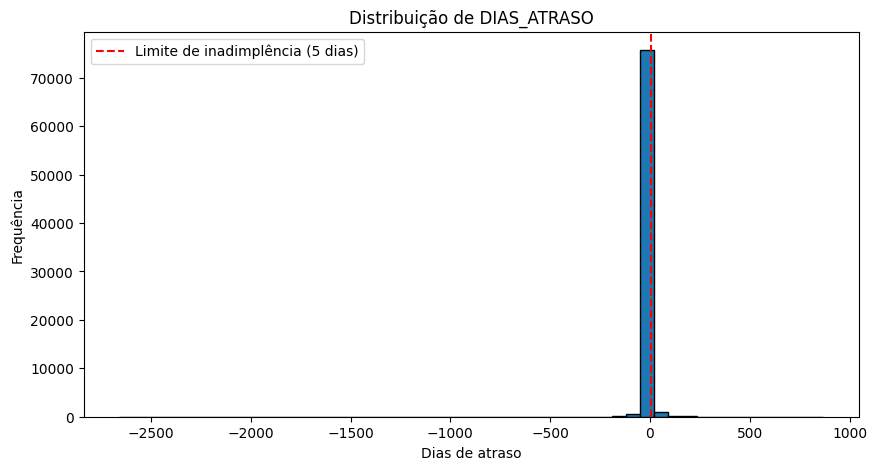

In [189]:
# Histograma da distribuição de DIAS_ATRASO (todos os registros)
plt.figure(figsize=(10, 5))
plt.hist(pagamentos_dev['DIAS_ATRASO'], bins=50, edgecolor='black')
plt.axvline(x=5, color='red', linestyle='--', label='Limite de inadimplência (5 dias)')
plt.xlabel('Dias de atraso')
plt.ylabel('Frequência')
plt.title('Distribuição de DIAS_ATRASO')
plt.legend()
plt.show()

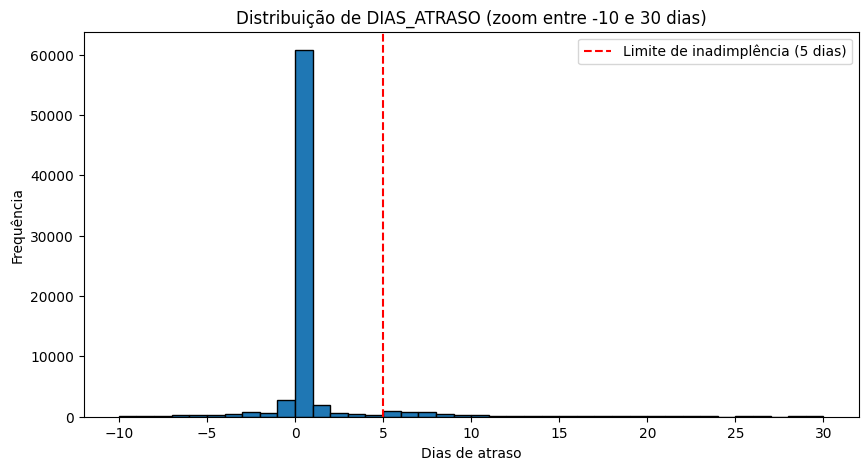

In [190]:
# Histograma focado na região entre -10 e 30 dias, para ver melhor o comportamento perto do corte
plt.figure(figsize=(10, 5))
plt.hist(pagamentos_dev['DIAS_ATRASO'], bins=40, range=(-10, 30), edgecolor='black')
plt.axvline(x=5, color='red', linestyle='--', label='Limite de inadimplência (5 dias)')
plt.xlabel('Dias de atraso')
plt.ylabel('Frequência')
plt.title('Distribuição de DIAS_ATRASO (zoom entre -10 e 30 dias)')
plt.legend()
plt.show()

In [191]:
# Investigando os outliers extremos de DIAS_ATRASO
outliers_negativos = pagamentos_dev[pagamentos_dev['DIAS_ATRASO'] < -365]
outliers_positivos = pagamentos_dev[pagamentos_dev['DIAS_ATRASO'] > 365]

print('Registros com atraso menor que -365 dias:', len(outliers_negativos))
print('Registros com atraso maior que 365 dias:', len(outliers_positivos))

# Olhando as linhas específicas para entender o padrão
print(outliers_negativos[['ID_CLIENTE', 'DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO', 'DATA_PAGAMENTO', 'DIAS_ATRASO']].head(10))
print(outliers_positivos[['ID_CLIENTE', 'DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO', 'DATA_PAGAMENTO', 'DIAS_ATRASO']].head(10))

Registros com atraso menor que -365 dias: 18
Registros com atraso maior que 365 dias: 7
                ID_CLIENTE DATA_EMISSAO_DOCUMENTO DATA_VENCIMENTO  \
2362   2451708306555441014             2018-09-20      2020-08-02   
3751   4593070249039532001             2018-10-03      2021-10-31   
5166   8724731934863284019             2018-11-04      2024-01-28   
5167   8724731934863284019             2018-11-04      2024-01-28   
15995  1366416810235233769             2019-03-27      2022-02-28   
27453  4820852183212661131             2019-08-29      2022-01-31   
27454  4820852183212661131             2019-08-29      2022-01-31   
33271  3829967475074118757             2019-12-01      2027-03-31   
34543  1097345589386012260             2019-11-20      2025-08-27   
36899  1118514612547157551             2019-12-29      2023-08-03   

      DATA_PAGAMENTO  DIAS_ATRASO  
2362      2018-10-08         -664  
3751      2018-10-22        -1105  
5166      2018-11-19        -1896  
5167    

In [192]:
# Verificando inconsistência lógica: vencimento não pode ser anterior à emissão
inconsistentes = pagamentos_dev[pagamentos_dev['DATA_VENCIMENTO'] < pagamentos_dev['DATA_EMISSAO_DOCUMENTO']]

print('Registros com DATA_VENCIMENTO anterior à DATA_EMISSAO_DOCUMENTO:', len(inconsistentes))
print(inconsistentes[['ID_CLIENTE', 'DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO', 'DATA_PAGAMENTO', 'DIAS_ATRASO']])

Registros com DATA_VENCIMENTO anterior à DATA_EMISSAO_DOCUMENTO: 27
                ID_CLIENTE DATA_EMISSAO_DOCUMENTO DATA_VENCIMENTO  \
1099   1118514612547157551             2018-09-02      2018-08-27   
1100   1118514612547157551             2018-09-02      2018-06-20   
1101   1118514612547157551             2018-09-02      2018-07-25   
1944   1977574645216036803             2018-09-13      2018-08-31   
2565   8198518259946944874             2018-10-12      2017-11-27   
5009   6020593949794792044             2018-11-06      2018-11-05   
5481   8198518259946944874             2018-11-13      2017-12-28   
8379   8348574220426911086             2019-01-03      2018-12-17   
16200  4442205629227031623             2019-03-24      2018-12-07   
16201  4442205629227031623             2019-03-24      2018-12-07   
18187   660382477567765256             2019-05-13      2019-01-23   
18188   660382477567765256             2019-05-13      2019-01-23   
25889  8047821974672655407         

In [193]:
# Checando a distribuição da target nos registros com inconsistência lógica
print(inconsistentes['TARGET_INADIMPLENCIA'].value_counts())
print(inconsistentes['TARGET_INADIMPLENCIA'].value_counts(normalize=True))

TARGET_INADIMPLENCIA
1    26
0     1
Name: count, dtype: int64
TARGET_INADIMPLENCIA
1    0.962963
0    0.037037
Name: proportion, dtype: float64


In [194]:
print(pagamentos_dev['TARGET_INADIMPLENCIA'].value_counts(normalize=True))

TARGET_INADIMPLENCIA
0    0.92978
1    0.07022
Name: proportion, dtype: float64


In [195]:
# Verificando se os nulos de VALOR_A_PAGAR se concentram em clientes específicos
clientes_com_valor_nulo = pagamentos_dev[pagamentos_dev['VALOR_A_PAGAR'].isna()]['ID_CLIENTE'].nunique()
print('Clientes distintos com VALOR_A_PAGAR nulo:', clientes_com_valor_nulo)

# Verificando se os nulos se concentram em alguma SAFRA_REF específica
print(pagamentos_dev[pagamentos_dev['VALOR_A_PAGAR'].isna()]['SAFRA_REF'].value_counts().head(10))

# Verificando se há relação entre VALOR_A_PAGAR nulo e a TARGET (inadimplência)
print(pagamentos_dev[pagamentos_dev['VALOR_A_PAGAR'].isna()]['TARGET_INADIMPLENCIA'].value_counts(normalize=True))

Clientes distintos com VALOR_A_PAGAR nulo: 525
SAFRA_REF
2019-05-01    43
2019-11-01    43
2021-03-01    42
2020-01-01    41
2021-05-01    40
2020-05-01    40
2021-01-01    40
2020-07-01    39
2019-12-01    39
2020-06-01    38
Name: count, dtype: int64
TARGET_INADIMPLENCIA
0    0.905983
1    0.094017
Name: proportion, dtype: float64


#### Base pagamentos - teste

In [196]:
# Visão geral da estrutura
pagamentos_teste.head()

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.75,4.99
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.50,5.99
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.50,5.99
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.00,5.99
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.95,6.99


In [197]:
# Visão geral da estrutura
pagamentos_teste.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12275 entries, 0 to 12274
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_CLIENTE              12275 non-null  int64  
 1   SAFRA_REF               12275 non-null  object 
 2   DATA_EMISSAO_DOCUMENTO  12275 non-null  object 
 3   DATA_VENCIMENTO         12275 non-null  object 
 4   VALOR_A_PAGAR           12144 non-null  float64
 5   TAXA                    12275 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 575.5+ KB


In [198]:
# Convertendo as datas (mesma lógica da base de desenvolvimento)
pagamentos_teste['DATA_EMISSAO_DOCUMENTO'] = pd.to_datetime(pagamentos_teste['DATA_EMISSAO_DOCUMENTO'])
pagamentos_teste['DATA_VENCIMENTO'] = pd.to_datetime(pagamentos_teste['DATA_VENCIMENTO'])
pagamentos_teste['SAFRA_REF'] = pd.to_datetime(pagamentos_teste['SAFRA_REF'], format='%Y-%m')

# Confirmando que não há sobreposição de período com a base de desenvolvimento
print('Menor SAFRA_REF no teste:', pagamentos_teste['SAFRA_REF'].min())
print('Maior SAFRA_REF no desenvolvimento:', pagamentos_dev['SAFRA_REF'].max())

# Distribuição de SAFRA_REF na base de teste
print(pagamentos_teste['SAFRA_REF'].value_counts().sort_index())

# Checando se DATA_VENCIMENTO nunca é anterior a DATA_EMISSAO_DOCUMENTO nesta base também
inconsistentes_teste = pagamentos_teste[pagamentos_teste['DATA_VENCIMENTO'] < pagamentos_teste['DATA_EMISSAO_DOCUMENTO']]
print('Inconsistências lógicas na base de teste:', len(inconsistentes_teste))

# Checando também se os ID_CLIENTE da base de teste existem na base de desenvolvimento (clientes novos vs recorrentes)
clientes_teste = set(pagamentos_teste['ID_CLIENTE'])
clientes_dev = set(pagamentos_dev['ID_CLIENTE'])
print('Clientes no teste que já existiam no desenvolvimento:', len(clientes_teste & clientes_dev))
print('Clientes totalmente novos no teste:', len(clientes_teste - clientes_dev))

Menor SAFRA_REF no teste: 2021-07-01 00:00:00
Maior SAFRA_REF no desenvolvimento: 2021-06-01 00:00:00
SAFRA_REF
2021-07-01    2529
2021-08-01    2654
2021-09-01    2667
2021-10-01    2673
2021-11-01    1752
Name: count, dtype: int64
Inconsistências lógicas na base de teste: 2
Clientes no teste que já existiam no desenvolvimento: 888
Clientes totalmente novos no teste: 88


In [199]:
inconsistentes_teste = pagamentos_teste[pagamentos_teste['DATA_VENCIMENTO'] < pagamentos_teste['DATA_EMISSAO_DOCUMENTO']]
print(inconsistentes_teste[['ID_CLIENTE', 'SAFRA_REF', 'DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO', 'VALOR_A_PAGAR', 'TAXA']])

               ID_CLIENTE  SAFRA_REF DATA_EMISSAO_DOCUMENTO DATA_VENCIMENTO  \
6463  5503073374822479037 2021-09-01             2021-09-13      2021-04-26   
6527  4095739077267179172 2021-09-01             2021-09-13      2021-04-26   

      VALOR_A_PAGAR  TAXA  
6463       25838.37  4.99  
6527       68695.44  5.99  


### Merges e Feature Engineering

In [200]:
# Unindo a base de pagamentos de desenvolvimento com a base de informações mensais
base_dev = pagamentos_dev.merge(
    info,
    on=['ID_CLIENTE', 'SAFRA_REF'],
    how='left'
)

# Unindo com a base cadastral, que é estática por cliente
base_dev = base_dev.merge(
    cadastral,
    on='ID_CLIENTE',
    how='left'
)

# Conferindo se o número de linhas se manteve igual ao da base de pagamentos original
print('Linhas em pagamentos_dev:', pagamentos_dev.shape[0])
print('Linhas em base_dev (apos merges):', base_dev.shape[0])

Linhas em pagamentos_dev: 77414
Linhas em base_dev (apos merges): 77414


In [201]:
# Verificando nulos gerados pelos merges na base de desenvolvimento
print(base_dev.isna().sum())

ID_CLIENTE                   0
SAFRA_REF                    0
DATA_EMISSAO_DOCUMENTO       0
DATA_PAGAMENTO               0
DATA_VENCIMENTO              0
VALOR_A_PAGAR             1170
TAXA                         0
DIAS_ATRASO                  0
TARGET_INADIMPLENCIA         0
RENDA_MES_ANTERIOR        6132
NO_FUNCIONARIOS           7587
DATA_CADASTRO                0
DDD                          0
FLAG_PF                      0
SEGMENTO_INDUSTRIAL          0
DOMINIO_EMAIL                0
PORTE                        0
CEP_2_DIG                    0
dtype: int64


In [202]:
# Replicando exatamente o mesmo pipeline de merge para a base de teste
base_teste = pagamentos_teste.merge(
    info,
    on=['ID_CLIENTE', 'SAFRA_REF'],
    how='left'
)

base_teste = base_teste.merge(
    cadastral,
    on='ID_CLIENTE',
    how='left'
)

print('Linhas em pagamentos_teste:', pagamentos_teste.shape[0])
print('Linhas em base_teste (apos merges):', base_teste.shape[0])

Linhas em pagamentos_teste: 12275
Linhas em base_teste (apos merges): 12275


In [203]:
# Verificando nulos gerados pelos merges na base de teste
print(base_teste.isna().sum())

ID_CLIENTE                   0
SAFRA_REF                    0
DATA_EMISSAO_DOCUMENTO       0
DATA_VENCIMENTO              0
VALOR_A_PAGAR              131
TAXA                         0
RENDA_MES_ANTERIOR         726
NO_FUNCIONARIOS           1167
DATA_CADASTRO               38
DDD                         38
FLAG_PF                     38
SEGMENTO_INDUSTRIAL         38
DOMINIO_EMAIL               38
PORTE                       38
CEP_2_DIG                   38
dtype: int64


In [204]:
# Quantos clientes únicos estão por trás dos 38 nulos de cadastral na base de teste?
print(base_teste[base_teste['DATA_CADASTRO'].isna()]['ID_CLIENTE'].nunique())

# Confirmando: esses são os mesmos clientes "novos" (sem histórico) que já haviamos identificado?
clientes_sem_cadastro = base_teste[base_teste['DATA_CADASTRO'].isna()]['ID_CLIENTE'].unique()
print(base_dev[base_dev['ID_CLIENTE'].isin(clientes_sem_cadastro)].shape[0])

21
0


In [205]:
# Verificando o período coberto por cada base, para confirmar se faz sentido criarmos variáveis
# temporais adicionais baseadas em DATA_VENCIMENTO

print("Base de Desenvolvimento")
print("SAFRA_REF - min:", base_dev['SAFRA_REF'].min(), "| max:", base_dev['SAFRA_REF'].max())
print("DATA_VENCIMENTO - min:", base_dev['DATA_VENCIMENTO'].min(), "| max:", base_dev['DATA_VENCIMENTO'].max())

print("\nBase de Teste")
print("SAFRA_REF - min:", base_teste['SAFRA_REF'].min(), "| max:", base_teste['SAFRA_REF'].max())
print("DATA_VENCIMENTO - min:", base_teste['DATA_VENCIMENTO'].min(), "| max:", base_teste['DATA_VENCIMENTO'].max())


Base de Desenvolvimento
SAFRA_REF - min: 2018-08-01 00:00:00 | max: 2021-06-01 00:00:00
DATA_VENCIMENTO - min: 2017-11-27 00:00:00 | max: 2027-03-31 00:00:00

Base de Teste
SAFRA_REF - min: 2021-07-01 00:00:00 | max: 2021-11-01 00:00:00
DATA_VENCIMENTO - min: 2021-04-26 00:00:00 | max: 2028-09-30 00:00:00


In [206]:
# Criação de features adicionais

# Marcando a origem de cada base antes de concatenar
base_dev['ORIGEM'] = 'dev'
base_teste['ORIGEM'] = 'teste'

# Concatenando as duas bases para calcular features que dependem do historico continuo do cliente
base_completa = pd.concat([base_dev, base_teste], ignore_index=True)

# Ordenando por cliente e data de vencimento, para que a contagem de cobrancas respeite a ordem cronologica
base_completa = base_completa.sort_values(by=['ID_CLIENTE', 'DATA_VENCIMENTO']).reset_index(drop=True)

# Criando a variavel ordinal que conta a sequencia de cobrancas de cada cliente ao longo do tempo
base_completa['NUMERO_COBRANCA_CLIENTE'] = base_completa.groupby('ID_CLIENTE').cumcount() + 1

# Criando a flag de registro inconsistente: emissao posterior ao vencimento
base_completa['FLAG_REGISTRO_INCONSISTENTE'] = (
    base_completa['DATA_EMISSAO_DOCUMENTO'] > base_completa['DATA_VENCIMENTO']).astype(int)

# Extraindo features temporais a partir da data de vencimento da cobranca
base_completa['DIA_COBRANCA'] = base_completa['DATA_VENCIMENTO'].dt.day
base_completa['MES_COBRANCA'] = base_completa['DATA_VENCIMENTO'].dt.month

# Criando variavel ordinal que mede o tempo de relacionamento do cliente com a empresa, em dias
base_completa['TEMPO_RELACIONAMENTO_DIAS'] = (base_completa['SAFRA_REF'] - base_completa['DATA_CADASTRO']).dt.days

# Construindo a taxa historica de inadimplencia do cliente, sem vazamento temporal
# QTD_COBRANCAS_ANTERIORES conta quantas cobrancas o cliente teve ANTES da atual (exclui a atual)
base_completa['QTD_COBRANCAS_ANTERIORES'] = base_completa.groupby('ID_CLIENTE').cumcount()

# QTD_INADIMPLENCIAS_ANTERIORES soma os targets anteriores, com shift(1) para excluir a cobranca atual
# Como a base de teste tem TARGET_INADIMPLENCIA como NaN, o cumsum ignora esses valores automaticamente
base_completa['QTD_INADIMPLENCIAS_ANTERIORES'] = (
    base_completa.groupby('ID_CLIENTE')['TARGET_INADIMPLENCIA']
    .transform(lambda x: x.shift(1).cumsum())
)

# Calculando a taxa historica; divisao por zero na primeira cobranca gera NaN, tratado a seguir
base_completa['TAXA_HISTORICA_INADIMPLENCIA'] = (
    base_completa['QTD_INADIMPLENCIAS_ANTERIORES'] / base_completa['QTD_COBRANCAS_ANTERIORES']
)

# Removendo colunas auxiliares que nao serao usadas como features do modelo
base_completa = base_completa.drop(columns=['QTD_COBRANCAS_ANTERIORES', 'QTD_INADIMPLENCIAS_ANTERIORES'])

# Tratando os nulos categoricos da base cadastral (clientes sem nenhum cadastro previo)
colunas_categoricas_cadastral = ['SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG', 'DDD', 'FLAG_PF']
for col in colunas_categoricas_cadastral:
    base_completa[col] = base_completa[col].fillna('Desconhecido')

# Separando novamente em desenvolvimento e teste, com base na flag de origem
base_dev_final = base_completa[base_completa['ORIGEM'] == 'dev'].drop(columns=['ORIGEM']).reset_index(drop=True)
base_teste_final = base_completa[base_completa['ORIGEM'] == 'teste'].drop(columns=['ORIGEM']).reset_index(drop=True)

# Conferindo se as contagens de linhas se mantiveram corretas apos a separacao
print('base_dev_final:', base_dev_final.shape[0], '| esperado:', base_dev.shape[0])
print('base_teste_final:', base_teste_final.shape[0], '| esperado:', base_teste.shape[0])

base_dev_final: 77414 | esperado: 77414
base_teste_final: 12275 | esperado: 12275


In [207]:
# Após resultado da modelagem, identificado que as colunas FLAG_PF e DDD não agregam valor 
# preditivo, então serão removidas das bases finais
colunas_para_remover = ['FLAG_PF', 'DDD']

base_dev_final = base_dev_final.drop(columns=colunas_para_remover)
base_teste_final = base_teste_final.drop(columns=colunas_para_remover)

In [208]:
# Verificando a distribuicao da nova variavel ordinal
print(base_dev_final['NUMERO_COBRANCA_CLIENTE'].describe())
print(base_teste_final['NUMERO_COBRANCA_CLIENTE'].describe())

# Conferindo uma amostra das novas colunas temporais
base_dev_final[['ID_CLIENTE', 'DATA_VENCIMENTO', 'NUMERO_COBRANCA_CLIENTE', 'DIA_COBRANCA', 'MES_COBRANCA']].head(10)

count    77414.000000
mean       103.285349
std        140.685948
min          1.000000
25%         24.000000
50%         59.000000
75%        119.000000
max       1151.000000
Name: NUMERO_COBRANCA_CLIENTE, dtype: float64
count    12275.000000
mean       194.962444
std        225.024136
min          1.000000
25%         70.000000
50%        128.000000
75%        229.000000
max       1325.000000
Name: NUMERO_COBRANCA_CLIENTE, dtype: float64


,ID_CLIENTE,DATA_VENCIMENTO,NUMERO_COBRANCA_CLIENTE,DIA_COBRANCA,MES_COBRANCA
0,8784237149961904,2018-09-04,1,4,9
1,8784237149961904,2018-09-10,2,10,9
2,8784237149961904,2018-09-10,3,10,9
3,8784237149961904,2018-09-11,4,11,9
4,8784237149961904,2018-09-11,5,11,9
5,8784237149961904,2018-09-24,6,24,9
6,8784237149961904,2018-09-24,7,24,9
7,8784237149961904,2018-09-25,8,25,9
8,8784237149961904,2018-09-27,9,27,9
9,8784237149961904,2018-10-03,10,3,10


### Modelagem

In [209]:
# Checando a distribuicao da target
print(base_dev_final['TARGET_INADIMPLENCIA'].value_counts())
print()
print(base_dev_final['TARGET_INADIMPLENCIA'].value_counts(normalize=True))

TARGET_INADIMPLENCIA
0.0    71978
1.0     5436
Name: count, dtype: int64

TARGET_INADIMPLENCIA
0.0    0.92978
1.0    0.07022
Name: proportion, dtype: float64


In [210]:
# Investigando os casos com atraso extremamente negativo
base_dev_final[base_dev_final['DIAS_ATRASO'] < -365].sort_values('DIAS_ATRASO')

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,DIAS_ATRASO,TARGET_INADIMPLENCIA,RENDA_MES_ANTERIOR,...,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG,NUMERO_COBRANCA_CLIENTE,FLAG_REGISTRO_INCONSISTENTE,DIA_COBRANCA,MES_COBRANCA,TEMPO_RELACIONAMENTO_DIAS,TAXA_HISTORICA_INADIMPLENCIA
30194,3829967475074118757,2019-12-01,2019-12-01,2019-12-17,2027-03-31,194329.49,5.99,-2661.0,0.0,207561.0,...,Serviços,YAHOO,GRANDE,48,379,0,31,3,4640.0,NaN
9946,1097345589386012260,2019-11-01,2019-11-20,2019-12-27,2025-08-27,659850.00,5.99,-2070.0,0.0,134947.0,...,Comércio,YAHOO,MEDIO,11,91,0,27,8,436.0,NaN
74436,8724731934863284019,2018-11-01,2018-11-04,2018-11-19,2024-01-28,40000.00,6.99,-1896.0,0.0,178799.0,...,Serviços,HOTMAIL,PEQUENO,60,172,0,28,1,6652.0,0.017544
74435,8724731934863284019,2018-11-01,2018-11-04,2018-11-19,2024-01-28,150000.00,6.99,-1896.0,0.0,178799.0,...,Serviços,HOTMAIL,PEQUENO,60,171,0,28,1,6652.0,NaN
72655,8535586342375301953,2021-03-01,2021-03-23,2021-04-07,2024-10-31,180000.00,11.99,-1303.0,0.0,315577.0,...,Comércio,YAHOO,MEDIO,36,129,0,31,10,1210.0,0.000000
72654,8535586342375301953,2021-03-01,2021-03-23,2021-04-13,2024-10-31,483816.00,11.99,-1297.0,0.0,315577.0,...,Comércio,YAHOO,MEDIO,36,128,0,31,10,1210.0,NaN
10814,1118514612547157551,2019-12-01,2019-12-29,2020-01-27,2023-08-03,401400.00,5.99,-1284.0,0.0,342370.0,...,Serviços,YAHOO,PEQUENO,78,496,0,3,8,2222.0,NaN
55292,6784879562354696650,2021-02-01,2021-02-02,2021-02-17,2024-06-30,1000000.00,5.99,-1229.0,0.0,693984.0,...,Desconhecido,YAHOO,MEDIO,85,152,0,30,6,7475.0,NaN
55293,6784879562354696650,2021-02-01,2021-02-02,2021-02-22,2024-06-30,628200.00,5.99,-1224.0,0.0,693984.0,...,Desconhecido,YAHOO,MEDIO,85,153,0,30,6,7475.0,0.144737
26002,3204108603682323936,2020-08-01,2020-08-19,2020-09-03,2023-11-30,140000.00,5.99,-1183.0,0.0,79093.0,...,Serviços,GMAIL,MEDIO,32,167,0,30,11,1808.0,NaN


In [211]:
base_dev_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77414 entries, 0 to 77413
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ID_CLIENTE                    77414 non-null  int64         
 1   SAFRA_REF                     77414 non-null  datetime64[ns]
 2   DATA_EMISSAO_DOCUMENTO        77414 non-null  datetime64[ns]
 3   DATA_PAGAMENTO                77414 non-null  datetime64[ns]
 4   DATA_VENCIMENTO               77414 non-null  datetime64[ns]
 5   VALOR_A_PAGAR                 76244 non-null  float64       
 6   TAXA                          77414 non-null  float64       
 7   DIAS_ATRASO                   77414 non-null  float64       
 8   TARGET_INADIMPLENCIA          77414 non-null  float64       
 9   RENDA_MES_ANTERIOR            71282 non-null  float64       
 10  NO_FUNCIONARIOS               69827 non-null  float64       
 11  DATA_CADASTRO               

In [212]:
# Verificando o intervalo de safras disponiveis na base de desenvolvimento
print(base_dev_final['SAFRA_REF'].min(), base_dev_final['SAFRA_REF'].max())
print(base_dev_final['SAFRA_REF'].value_counts().sort_index())

2018-08-01 00:00:00 2021-06-01 00:00:00
SAFRA_REF
2018-08-01     992
2018-09-01    1992
2018-10-01    2096
2018-11-01    2122
2018-12-01    2059
2019-01-01    2299
2019-02-01    1971
2019-03-01    2247
2019-04-01    2058
2019-05-01    2317
2019-06-01    2231
2019-07-01    2343
2019-08-01    2291
2019-09-01    2373
2019-10-01    2464
2019-11-01    2377
2019-12-01    2448
2020-01-01    2414
2020-02-01    2210
2020-03-01    1984
2020-04-01    1780
2020-05-01    1904
2020-06-01    2052
2020-07-01    2287
2020-08-01    2249
2020-09-01    2382
2020-10-01    2402
2020-11-01    2471
2020-12-01    2332
2021-01-01    2393
2021-02-01    2146
2021-03-01    2326
2021-04-01    2358
2021-05-01    2531
2021-06-01    2513
Name: count, dtype: int64


In [213]:
# Definindo o corte temporal: ultimos 6 meses para validacao
safra_corte = '2021-01-01'

treino = base_dev_final[base_dev_final['SAFRA_REF'] < safra_corte].copy()
validacao = base_dev_final[base_dev_final['SAFRA_REF'] >= safra_corte].copy()

print('Treino:', treino.shape[0], 'registros', f"({treino.shape[0] / base_dev_final.shape[0]:.1%})")
print('Validacao:', validacao.shape[0], 'registros', f"({validacao.shape[0] / base_dev_final.shape[0]:.1%})")

# Checando se a proporcao da target se manteve parecida nos dois conjuntos
print('\nProporcao TARGET_INADIMPLENCIA - Treino:')
print(treino['TARGET_INADIMPLENCIA'].value_counts(normalize=True))
print('\nProporcao TARGET_INADIMPLENCIA - Validacao:')
print(validacao['TARGET_INADIMPLENCIA'].value_counts(normalize=True))

Treino: 63147 registros (81.6%)
Validacao: 14267 registros (18.4%)

Proporcao TARGET_INADIMPLENCIA - Treino:
TARGET_INADIMPLENCIA
0.0    0.92812
1.0    0.07188
Name: proportion, dtype: float64

Proporcao TARGET_INADIMPLENCIA - Validacao:
TARGET_INADIMPLENCIA
0.0    0.937128
1.0    0.062872
Name: proportion, dtype: float64


#### Treinamento dos modelos

In [214]:
# Definindo as colunas categoricas
colunas_categoricas = ['SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG']

# Convertendo para o tipo category (necessario para uso nativo em LGBM e XGBoost)
for df in [treino, validacao]:
    for col in colunas_categoricas:
        df[col] = df[col].astype('category')

# Definindo as colunas a serem excluidas da modelagem (identificadores, datas brutas e vazamento de dados)
colunas_excluir = [
    'ID_CLIENTE', 'SAFRA_REF', 'DATA_EMISSAO_DOCUMENTO',
    'DATA_PAGAMENTO', 'DATA_VENCIMENTO', 'DATA_CADASTRO',
    'DIAS_ATRASO', 'TARGET_INADIMPLENCIA'
]

features = [col for col in treino.columns if col not in colunas_excluir]

X_train = treino[features]
y_train = treino['TARGET_INADIMPLENCIA']

X_val = validacao[features]
y_val = validacao['TARGET_INADIMPLENCIA']

print('Features utilizadas:', features)
print('Shape X_train:', X_train.shape)
print('Shape X_val:', X_val.shape)

Features utilizadas: ['VALOR_A_PAGAR', 'TAXA', 'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG', 'NUMERO_COBRANCA_CLIENTE', 'FLAG_REGISTRO_INCONSISTENTE', 'DIA_COBRANCA', 'MES_COBRANCA', 'TEMPO_RELACIONAMENTO_DIAS', 'TAXA_HISTORICA_INADIMPLENCIA']
Shape X_train: (63147, 14)
Shape X_val: (14267, 14)


In [215]:
# Calculando o peso da classe positiva com base no desbalanceamento do treino
contagem_negativos = (y_train == 0).sum()
contagem_positivos = (y_train == 1).sum()
scale_pos_weight = contagem_negativos / contagem_positivos

print(f'Proporcao negativo/positivo (scale_pos_weight): {scale_pos_weight:.2f}')

# Lista para armazenar os resultados de cada modelo, para comparacao posterior
resultados_modelos = []

Proporcao negativo/positivo (scale_pos_weight): 12.91


In [216]:
inicio = time.time()

modelo_lgbm = lgb.LGBMClassifier(
    random_state=42,
    is_unbalance=True,
    n_estimators=500
)

modelo_lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='aucpr',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=50)]
)

tempo_lgbm = time.time() - inicio

pred_lgbm = modelo_lgbm.predict_proba(X_val)[:, 1]

auc_roc_lgbm = roc_auc_score(y_val, pred_lgbm)
auc_pr_lgbm = average_precision_score(y_val, pred_lgbm)

resultados_modelos.append({
    'Modelo': 'LightGBM',
    'AUC-ROC': auc_roc_lgbm,
    'AUC-PR': auc_pr_lgbm,
    'Tempo (s)': tempo_lgbm
})

print(f"\nLightGBM - AUC-ROC: {auc_roc_lgbm:.4f} | AUC-PR: {auc_pr_lgbm:.4f} | Tempo: {tempo_lgbm:.2f}s")

[LightGBM] [Info] Number of positive: 4539, number of negative: 58608
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003710 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.


c:\Users\Gabriel\anaconda3\envs\datarisk-case\lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Total Bins 1552
[LightGBM] [Info] Number of data points in the train set: 63147, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.071880 -> initscore=-2.558164
[LightGBM] [Info] Start training from score -2.558164
Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.299906
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.206875

LightGBM - AUC-ROC: 0.9022 | AUC-PR: 0.4114 | Tempo: 0.97s


In [217]:
inicio = time.time()

modelo_xgb = xgb.XGBClassifier(
    random_state=42,
    enable_categorical=True,
    tree_method='hist',
    scale_pos_weight=scale_pos_weight,
    n_estimators=500,
    eval_metric='aucpr',
    early_stopping_rounds=50
)

modelo_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

tempo_xgb = time.time() - inicio

pred_xgb = modelo_xgb.predict_proba(X_val)[:, 1]

auc_roc_xgb = roc_auc_score(y_val, pred_xgb)
auc_pr_xgb = average_precision_score(y_val, pred_xgb)

resultados_modelos.append({
    'Modelo': 'XGBoost',
    'AUC-ROC': auc_roc_xgb,
    'AUC-PR': auc_pr_xgb,
    'Tempo (s)': tempo_xgb
})

print(f"\nXGBoost - AUC-ROC: {auc_roc_xgb:.4f} | AUC-PR: {auc_pr_xgb:.4f} | Tempo: {tempo_xgb:.2f}s")

[0]	validation_0-aucpr:0.45563
[50]	validation_0-aucpr:0.47570
[67]	validation_0-aucpr:0.47862

XGBoost - AUC-ROC: 0.8963 | AUC-PR: 0.5178 | Tempo: 2.54s


In [218]:
inicio = time.time()

modelo_catboost = CatBoostClassifier(
    random_state=42,
    cat_features=colunas_categoricas,
    scale_pos_weight=scale_pos_weight,
    n_estimators=500,
    eval_metric='PRAUC',
    early_stopping_rounds=50,
    verbose=50
)

modelo_catboost.fit(
    X_train, y_train,
    eval_set=(X_val, y_val)
)

tempo_catboost = time.time() - inicio

pred_catboost = modelo_catboost.predict_proba(X_val)[:, 1]

auc_roc_catboost = roc_auc_score(y_val, pred_catboost)
auc_pr_catboost = average_precision_score(y_val, pred_catboost)

resultados_modelos.append({
    'Modelo': 'CatBoost',
    'AUC-ROC': auc_roc_catboost,
    'AUC-PR': auc_pr_catboost,
    'Tempo (s)': tempo_catboost
})

print(f"\nCatBoost - AUC-ROC: {auc_roc_catboost:.4f} | AUC-PR: {auc_pr_catboost:.4f} | Tempo: {tempo_catboost:.2f}s")

Learning rate set to 0.119274
0:	learn: 0.8957850	test: 0.8823327	best: 0.8823327 (0)	total: 287ms	remaining: 2m 23s
50:	learn: 0.9362477	test: 0.9075436	best: 0.9075436 (50)	total: 8.51s	remaining: 1m 14s
100:	learn: 0.9474620	test: 0.9111952	best: 0.9113211 (99)	total: 16.4s	remaining: 1m 4s
150:	learn: 0.9578267	test: 0.9147894	best: 0.9151477 (149)	total: 25s	remaining: 57.7s
200:	learn: 0.9649200	test: 0.9130045	best: 0.9160269 (158)	total: 33.2s	remaining: 49.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9160269049
bestIteration = 158

Shrink model to first 159 iterations.

CatBoost - AUC-ROC: 0.9269 | AUC-PR: 0.5587 | Tempo: 34.93s


In [219]:
df_resultados = pd.DataFrame(resultados_modelos)
df_resultados

,Modelo,AUC-ROC,AUC-PR,Tempo (s)
0,LightGBM,0.902206,0.411354,0.974876
1,XGBoost,0.896328,0.517801,2.543944
2,CatBoost,0.926910,0.558731,34.929005


In [220]:
importancia_catboost = pd.DataFrame({
    'Feature': modelo_catboost.feature_names_,
    'Importancia': modelo_catboost.get_feature_importance()
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

importancia_catboost

,Feature,Importancia
0,TAXA_HISTORICA_INADIMPLENCIA,18.223532
1,MES_COBRANCA,13.753623
2,NUMERO_COBRANCA_CLIENTE,12.987835
3,VALOR_A_PAGAR,11.810516
4,TEMPO_RELACIONAMENTO_DIAS,7.956682
5,CEP_2_DIG,7.817025
6,DIA_COBRANCA,5.647663
7,RENDA_MES_ANTERIOR,4.779500
8,NO_FUNCIONARIOS,4.418114
9,SEGMENTO_INDUSTRIAL,3.917537


In [221]:
importancia_xgb = pd.DataFrame({
    'Feature': modelo_xgb.feature_names_in_,
    'Importancia': modelo_xgb.feature_importances_
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

importancia_xgb

,Feature,Importancia
0,TAXA_HISTORICA_INADIMPLENCIA,0.507984
1,VALOR_A_PAGAR,0.100551
2,MES_COBRANCA,0.083288
3,CEP_2_DIG,0.069369
4,NUMERO_COBRANCA_CLIENTE,0.035412
5,FLAG_REGISTRO_INCONSISTENTE,0.033825
6,TEMPO_RELACIONAMENTO_DIAS,0.025693
7,SEGMENTO_INDUSTRIAL,0.024883
8,RENDA_MES_ANTERIOR,0.024020
9,DIA_COBRANCA,0.023131


In [222]:
from scipy.stats.contingency import association

tabela_contingencia = pd.crosstab(base_completa['DDD'], base_completa['CEP_2_DIG'])
v = association(tabela_contingencia, method='cramer')
print(f"V de Cramer entre DDD e CEP_2_DIG: {v:.4f}")

V de Cramer entre DDD e CEP_2_DIG: 0.6287


### Interpretação de resultados e otimização de hiperparâmetros

In [224]:
# Otimização de hiperparâmetros do XGBoost usando Optuna
# Reaproveitando o split temporal ja definido (data fixa de SAFRA_REF)
# X_train, y_train, X_val, y_val ja devem estar no ambiente

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'n_estimators': 1000,
        'scale_pos_weight': scale_pos_weight,
        'eval_metric': 'aucpr',
        'early_stopping_rounds': 50,
        'enable_categorical': True,
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1
    }

    modelo = XGBClassifier(**params)
    modelo.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_pred_proba = modelo.predict_proba(X_val)[:, 1]
    aucpr = average_precision_score(y_val, y_pred_proba)

    return aucpr

study_xgb = optuna.create_study(direction='maximize', study_name='xgboost_aucpr')
study_xgb.optimize(objective, n_trials=50)

print('Melhor AUC-PR:', study_xgb.best_value)
print('Melhores parametros:', study_xgb.best_params)

[I 2026-07-29 11:16:33,360] A new study created in memory with name: xgboost_aucpr
[I 2026-07-29 11:16:37,299] Trial 0 finished with value: 0.5698135226717295 and parameters: {'max_depth': 7, 'learning_rate': 0.05124493635017284, 'subsample': 0.9428011772729963, 'colsample_bytree': 0.8170620459208737, 'min_child_weight': 13, 'reg_alpha': 0.02169506207944761, 'reg_lambda': 0.03963792129981608}. Best is trial 0 with value: 0.5698135226717295.
[I 2026-07-29 11:16:44,686] Trial 1 finished with value: 0.574863970010705 and parameters: {'max_depth': 8, 'learning_rate': 0.013903669850793698, 'subsample': 0.6082393627943841, 'colsample_bytree': 0.591487937188516, 'min_child_weight': 20, 'reg_alpha': 4.092813302924464e-06, 'reg_lambda': 0.009956634303444624}. Best is trial 1 with value: 0.574863970010705.
[I 2026-07-29 11:16:51,250] Trial 2 finished with value: 0.5614962787305281 and parameters: {'max_depth': 10, 'learning_rate': 0.0502273158030382, 'subsample': 0.505030728150587, 'colsample_by

Melhor AUC-PR: 0.5885881288545289
Melhores parametros: {'max_depth': 4, 'learning_rate': 0.12458112490657876, 'subsample': 0.5700929317955347, 'colsample_bytree': 0.6413318068104654, 'min_child_weight': 9, 'reg_alpha': 1.4222708578354587e-08, 'reg_lambda': 2.1982032452428437e-06}


In [225]:
best_params_xgb = study_xgb.best_params

modelo_xgb_final = XGBClassifier(
    **best_params_xgb,
    n_estimators=1000,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    enable_categorical=True,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

modelo_xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print('Melhor iteracao:', modelo_xgb_final.best_iteration)
print('Melhor score (AUC-PR):', modelo_xgb_final.best_score)

Melhor iteracao: 109
Melhor score (AUC-PR): 0.5878571488179732


In [226]:
# Otimização de hiperparâmetros do CatBoost usando Optuna
colunas_categoricas = ['SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG']

def objective_catboost(trial):
    params = {
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'iterations': 1000,
        'scale_pos_weight': scale_pos_weight,
        'eval_metric': 'PRAUC',
        'early_stopping_rounds': 50,
        'cat_features': colunas_categoricas,
        'bootstrap_type': 'Bernoulli',
        'random_state': 42,
        'verbose': False
    }

    modelo = CatBoostClassifier(**params)
    modelo.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    y_pred_proba = modelo.predict_proba(X_val)[:, 1]
    aucpr = average_precision_score(y_val, y_pred_proba)

    return aucpr

study_catboost = optuna.create_study(direction='maximize', study_name='catboost_aucpr')
study_catboost.optimize(objective_catboost, n_trials=30)

print('Melhor AUC-PR:', study_catboost.best_value)
print('Melhores parametros:', study_catboost.best_params)

[I 2026-07-29 11:22:31,247] A new study created in memory with name: catboost_aucpr
[I 2026-07-29 11:22:56,666] Trial 0 finished with value: 0.5488500513650338 and parameters: {'depth': 5, 'learning_rate': 0.07850954675286842, 'subsample': 0.648623616021867, 'colsample_bylevel': 0.9253326775387608, 'min_data_in_leaf': 37, 'l2_leaf_reg': 0.12035060678136153}. Best is trial 0 with value: 0.5488500513650338.
[I 2026-07-29 11:23:20,643] Trial 1 finished with value: 0.5472339807931906 and parameters: {'depth': 3, 'learning_rate': 0.1579367116263897, 'subsample': 0.8495475655572122, 'colsample_bylevel': 0.7941219074433757, 'min_data_in_leaf': 21, 'l2_leaf_reg': 0.34238986985680914}. Best is trial 0 with value: 0.5488500513650338.
[I 2026-07-29 11:24:50,855] Trial 2 finished with value: 0.5318485808373461 and parameters: {'depth': 4, 'learning_rate': 0.010184935162842055, 'subsample': 0.6407181991819395, 'colsample_bylevel': 0.7047807564324555, 'min_data_in_leaf': 8, 'l2_leaf_reg': 3.14440738

Melhor AUC-PR: 0.5642493149708917
Melhores parametros: {'depth': 6, 'learning_rate': 0.053400572952057086, 'subsample': 0.7121274360785482, 'colsample_bylevel': 0.663848638582525, 'min_data_in_leaf': 18, 'l2_leaf_reg': 8.908447826192152}


In [227]:
best_params_catboost = study_catboost.best_params

modelo_catboost_final = CatBoostClassifier(
    **best_params_catboost,
    iterations=1000,
    scale_pos_weight=scale_pos_weight,
    eval_metric='PRAUC',
    early_stopping_rounds=50,
    cat_features=colunas_categoricas,
    bootstrap_type='Bernoulli',
    random_state=42,
    verbose=False
)

modelo_catboost_final.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

print('Melhor iteracao:', modelo_catboost_final.get_best_iteration())
print('Melhor score (AUC-PR):', modelo_catboost_final.get_best_score())

Melhor iteracao: 422
Melhor score (AUC-PR): {'learn': {'Logloss': 0.2335669376915076, 'PRAUC': 0.9644714934819095}, 'validation': {'Logloss': 0.34169017214846237, 'PRAUC': 0.9168764335524522}}
